# 05_a — Recovered Cells U-Net (Modeling Pipeline)

**Experiment:** Recover dropped cells via left-join from Wikipedia labels.  
**Baseline:** The inner-join in notebook `03` used only the 149 cells that appear in *both* the ACLED feature matrix and the Wikipedia label table. This experiment switches to a **left join from labels**, recovering 36 additional cells that Wikipedia annotated but ACLED recorded zero events for — genuinely quiet zones that are still meaningful for territorial control mapping.

**Key changes vs baseline:**
| Setting | Baseline (03) | This experiment (05_a) |
|---|---|---|
| Join direction | inner (features → labels) | **left (labels → features)** |
| Labelled cells | 149 | **185** |
| Zero-event cells | excluded | **included as all-zeros** |
| Focal mask weight | none | **1.0 focal / 0.0 outside** |

**What to expect:** More spatial coverage, especially in stable-government periphery.  
The focal mask concentrates the CE gradient on the contested frontier, preventing the extra stable cells from washing out the loss signal.


---
## 1 · Reproducibility

Every source of randomness in Python, NumPy, PyTorch CPU, and (if present) MPS/CUDA is seeded to the same project-wide constant before any data is touched. This guarantees that re-running the notebook top-to-bottom always produces identical weights and metrics.


In [1]:
# ── CELL 0: Reproducibility ──────────────────────────────────────────────────
import random, os
import numpy as np
import torch

SEED = 20269999

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
if hasattr(torch.backends, 'mps'):
    torch.mps.manual_seed(SEED) if hasattr(torch.mps, 'manual_seed') else None
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f'Global seed fixed: {SEED}')


Global seed fixed: 20269999


---
## 2 · Configuration

All experiment hyperparameters live here. Change `TRAIN_CUTOFF` to shift the temporal split; everything downstream adapts automatically.

| Parameter | Value | Meaning |
|---|---|---|
| `TRAIN_CUTOFF` | `2025-01` | Last month included in training |
| `NEIGHBOR_RADIUS` | `1` | Queen-contiguity dilation of focal mask |
| `FOCAL_OUT_WEIGHT` | `0.0` | CE weight for cells outside focal region |
| `NUM_EPOCHS` | `200` | Total training epochs |
| `FREEZE_EPOCHS` | `30` | Epochs before encoder is unfrozen |
| `LEARNING_RATE` | `1e-4` | Decoder learning rate (Phase 1) |
| `UNFREEZE_LR` | `1e-5` | Full-model LR (Phase 2) |

**Two-phase strategy:** The ResNet34 encoder starts frozen (pre-trained ImageNet weights intact) while only the lightweight decoder is updated. After epoch 30 the encoder is unfrozen with a 10× lower LR for fine-tuning. This prevents catastrophic forgetting when data is scarce (≈15 training months).


In [2]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
TRAIN_CUTOFF    = '2025-01'
EXPERIMENT_NAME = '05_a_recovered_cells'

NEIGHBOR_RADIUS  = 1
FOCAL_OUT_WEIGHT = 0.0

NUM_EPOCHS    = 200
BATCH_SIZE    = 8
LEARNING_RATE = 1e-4
FREEZE_EPOCHS = 30
UNFREEZE_LR   = 1e-5

CHECKPOINT_EXP = f'{EXPERIMENT_NAME}/unet_a_best.pt'

print(f'Experiment      : {EXPERIMENT_NAME}')
print(f'Train cutoff    : {TRAIN_CUTOFF}')
print(f'Neighbor radius : {NEIGHBOR_RADIUS}')
print(f'Focal out wt    : {FOCAL_OUT_WEIGHT}')
print(f'Epochs          : {NUM_EPOCHS}')


Experiment      : 05_a_recovered_cells
Train cutoff    : 2025-01
Neighbor radius : 1
Focal out wt    : 0.0
Epochs          : 200


---
## 3 · Data Loading

### Target variable
The target variable (`10_target_variable.parquet`) is a PRIOGRID cell × month panel with three classes:

| Class | Meaning |
|---|---|
| `gov` | Cell under government (SAC/Tatmadaw) control |
| `opo` | Cell under opposition / EAO control |
| `uncertain` | Contested or ambiguous control |

Labels are derived from Wikipedia article edits (primary) and cross-checked against ACLED event patterns (secondary). The label table covers **185 cells** — 36 more than the ACLED feature matrix alone.


In [3]:
# ── CELL 1: Imports, Paths, Target Variable ───────────────────────────────────
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from scipy.ndimage import binary_dilation
import copy, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('../..').resolve()
DATA_RAW     = PROJECT_ROOT / 'data' / 'raw'
DATA_PROC    = PROJECT_ROOT / 'data' / 'processed'
REPORTS      = PROJECT_ROOT / 'reports' / 'figures'
MODELS_DIR   = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

target = pd.read_parquet(DATA_PROC / '10_target_variable.parquet')
target['year_month'] = target['year_month'].astype(str)

print(f'Target rows: {len(target):,}  |  months: {target["year_month"].nunique()}'
      f'  |  cells: {target["priogrid_gid"].nunique()}')
print('\nClass distribution:')
print(target['target'].value_counts())


/Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Target rows: 5,238  |  months: 29  |  cells: 185

Class distribution:
target
gov          3303
opo          1110
uncertain     825
Name: count, dtype: int64


---
## 4 · Raster Dataset Construction

### Why rasters?
U-Net is a *spatial* model: its encoder–decoder architecture learns from the 2-D neighbourhood of each cell, not just the cell in isolation. To use it, we must convert the flat (cell × month) panel into stacked 2-D images, one per month.

### Key design: left join from labels
```
baseline (03):  features  ──inner join──►  labelled  (149 cells)
this experiment: labels   ──left join──►   labelled  (185 cells)
```
The 36 extra cells have Wikipedia annotations but zero ACLED events. Their feature vector is filled with **0.0 before z-scoring**, which after normalisation maps to roughly `−0.5` standard deviations — correctly representing "genuinely quiet, below-average conflict." Crucially, this fill happens *before* we compute training statistics, so the normalisation is leak-free.

### Raster geometry
Each monthly raster is a `40 × 16` grid (padded to the nearest multiple of 8 for U-Net pooling). Cells outside the label table remain at zero-features and are masked out of the loss.


In [4]:
# ── CELL 2: Build Raster Dataset  [05_a: left join from labels] ──────────────
# KEY CHANGE: left join FROM target (185 cells) rather than inner join.
# The 36 cells with Wikipedia labels but no UCDP events get 0.0 features
# BEFORE z-scoring → they correctly represent "genuinely quiet" areas.
from sklearn.preprocessing import LabelEncoder

features = pd.read_csv(DATA_PROC / 'myanmar_priogrid_features.csv')
features['year_month'] = features['year_month'].astype(str)

INPUT_FEATURES = [
    'total_events', 'total_fatalities', 'events_gov', 'events_nug',
    'events_ula', 'events_kio', 'gov_vs_civilians', 'gov_event_share',
    'total_events_lag1', 'total_fatalities_lag1',
]
NUM_CHANNELS = len(INPUT_FEATURES)

def gid_to_rowcol(gid):
    return (gid - 1) // 720, (gid - 1) % 720

all_gids = features['priogrid_gid'].unique()
gid_coords = {}
for gid in all_gids:
    r, c = gid_to_rowcol(gid)
    gid_coords[gid] = {'global_row': r, 'global_col': c}
coords_df = pd.DataFrame.from_dict(gid_coords, orient='index')
coords_df.index.name = 'priogrid_gid'

min_global_row = coords_df['global_row'].min()
min_global_col = coords_df['global_col'].min()
coords_df['local_row'] = coords_df['global_row'] - min_global_row
coords_df['local_col'] = coords_df['global_col'] - min_global_col

RASTER_H = coords_df['local_row'].max() + 1
RASTER_W = coords_df['local_col'].max() + 1
PAD_H    = int(np.ceil(RASTER_H / 8) * 8)
PAD_W    = int(np.ceil(RASTER_W / 8) * 8)

gid_to_local = coords_df[['local_row','local_col']].to_dict('index')

LABEL_MAP = {'gov': 0, 'opo': 1, 'uncertain': 2}
INV_LABEL = {v: k for k, v in LABEL_MAP.items()}
CLASS_NAMES = ['gov', 'opo', 'uncertain']

labelled = target[['priogrid_gid','year_month','target']].merge(
    features, on=['priogrid_gid','year_month'], how='left'
)
labelled[INPUT_FEATURES] = labelled[INPUT_FEATURES].fillna(0.0)
labelled['label_int'] = labelled['target'].map(LABEL_MAP)

for gid in labelled['priogrid_gid'].unique():
    if gid in gid_to_local:
        continue
    r0, c0 = gid_to_rowcol(gid)
    lr = r0 - min_global_row
    lc = c0 - min_global_col
    if 0 <= lr < PAD_H and 0 <= lc < PAD_W:
        gid_to_local[gid] = {'local_row': lr, 'local_col': lc}

n_recovered = len(labelled['priogrid_gid'].unique()) - len(all_gids)
n_in_raster = sum(1 for g in labelled['priogrid_gid'].unique() if g in gid_to_local)
print(f'Left join: {labelled["priogrid_gid"].nunique()} unique cells'
      f'  ({n_recovered:+d} vs inner-join baseline)')
print(f'Cells mappable to raster: {n_in_raster}')

train_mask_rows = labelled['year_month'] <= TRAIN_CUTOFF
train_months_used = sorted(labelled.loc[train_mask_rows, 'year_month'].unique())
feat_means = labelled.loc[train_mask_rows, INPUT_FEATURES].mean()
feat_stds  = labelled.loc[train_mask_rows, INPUT_FEATURES].std().replace(0, 1)
print(f'\nNormalisation fit on {len(train_months_used)} training months:')
print(f'  {train_months_used[0]} → {train_months_used[-1]}')
labelled[INPUT_FEATURES] = (labelled[INPUT_FEATURES] - feat_means) / feat_stds

months_with_labels = sorted(labelled['year_month'].unique())
X_rasters, y_rasters, masks_r, month_keys = [], [], [], []

for month in months_with_labels:
    md_  = labelled[labelled['year_month'] == month]
    X_r  = np.zeros((PAD_H, PAD_W, NUM_CHANNELS), dtype=np.float32)
    y_r  = np.full( (PAD_H, PAD_W), fill_value=-1, dtype=np.int64)
    msk  = np.zeros((PAD_H, PAD_W), dtype=np.uint8)
    for _, row in md_.iterrows():
        gid = row['priogrid_gid']
        if gid not in gid_to_local: continue
        lr, lc = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
        X_r[lr, lc, :] = row[INPUT_FEATURES].values
        y_r[lr, lc]    = row['label_int']
        msk[lr, lc]    = 1
    X_rasters.append(np.transpose(X_r, (2,0,1)))
    y_rasters.append(y_r); masks_r.append(msk); month_keys.append(month)

X_array = np.stack(X_rasters); y_array = np.stack(y_rasters); m_array = np.stack(masks_r)

train_idx = [i for i, m in enumerate(month_keys) if m <= TRAIN_CUTOFF]
val_idx   = [i for i, m in enumerate(month_keys) if m >  TRAIN_CUTOFF]
X_train, y_train, m_train = X_array[train_idx], y_array[train_idx], m_array[train_idx]
X_val,   y_val,   m_val   = X_array[val_idx],   y_array[val_idx],   m_array[val_idx]
val_month_keys = [month_keys[i] for i in val_idx]

print(f'Raster shape: {X_array.shape}  (months x channels x H x W)')
print(f'Avg labelled cells/month: {m_array.sum(axis=(1,2)).mean():.0f}')
print(f'Train months: {len(train_idx)}  ({month_keys[train_idx[0]]} → {month_keys[train_idx[-1]]})')
print(f'Val   months: {len(val_idx)}   ({month_keys[val_idx[0]]} → {month_keys[val_idx[-1]]})')


Left join: 185 unique cells  (-14 vs inner-join baseline)
Cells mappable to raster: 183

Normalisation fit on 15 training months:
  2023-11 → 2025-01
Raster shape: (29, 10, 40, 16)  (months x channels x H x W)
Avg labelled cells/month: 179
Train months: 15  (2023-11 → 2025-01)
Val   months: 14   (2025-02 → 2026-03)


---
## 5 · Focal Mask

### The class-imbalance problem in space
Myanmar's conflict is highly concentrated. The majority of labelled cells remain under stable government control throughout the observation window. If every cell contributes equally to the loss, the model is rewarded for simply predicting "gov" everywhere and never learns the contested frontier.

### Solution: focal gradient masking
We identify the cells that **ever change** control class across all 29 months. We then **dilate** that set by one cell in every direction (queen contiguity, radius = 1), capturing the immediate spatial context of contested areas. The CE loss is computed with **full weight only inside this focal region**; cells outside it contribute weight `FOCAL_OUT_WEIGHT = 0.0`.

The Dice loss is still computed over the full labelled region — this preserves the spatial shape signal and prevents the encoder from ignoring stable areas entirely.

> The focal mask is saved to `models/focal_mask_r{radius}.npy` so the evaluation notebook can reproduce identical masking without re-running training.


Total labelled cells      : 185
Cells that change label   : 94  (50.8%)
Cells always stable       : 91

── Focal Mask Statistics (radius=1) ──
  Focal mask pixels        : 285 / 640  (44.5% of raster)
  Avg labelled cells/month : 179
  Train cell-months in focal mask     : 2,243 / 2,618 (85.7%)
  Of those, cells that ever change    : 1,338 (59.7%)

Focal mask saved to: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/models/focal_mask_r1.npy


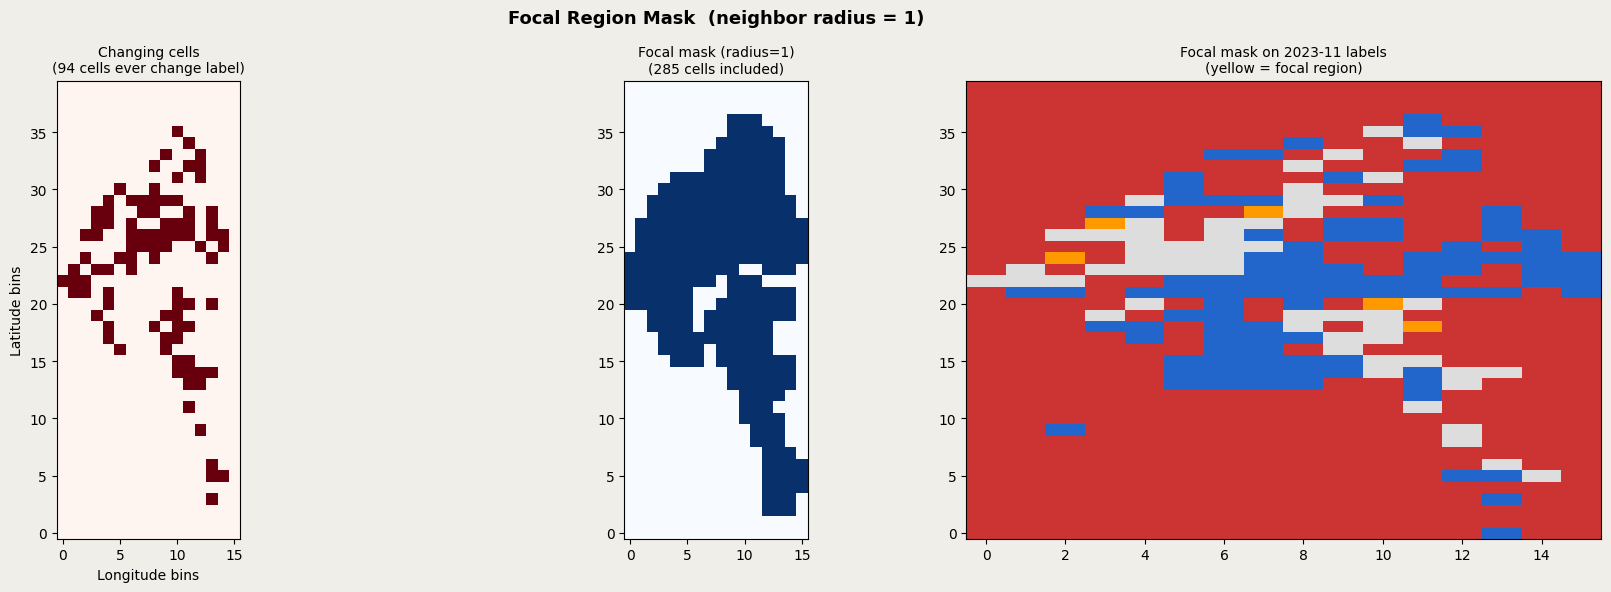

Focal mask figure saved.


In [5]:
# ── CELL 3: Build Focal Mask ─────────────────────────────────────────────────
label_by_gid = labelled.groupby('priogrid_gid')['label_int'].nunique()
changing_gids = set(label_by_gid[label_by_gid > 1].index)

print(f'Total labelled cells      : {len(label_by_gid):,}')
print(f'Cells that change label   : {len(changing_gids):,}'
      f'  ({100*len(changing_gids)/len(label_by_gid):.1f}%)')
print(f'Cells always stable       : {len(label_by_gid) - len(changing_gids):,}')

changing_raster = np.zeros((PAD_H, PAD_W), dtype=bool)
for gid in changing_gids:
    if gid in gid_to_local:
        lr, lc = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
        changing_raster[lr, lc] = True

struct = np.ones((2*NEIGHBOR_RADIUS+1, 2*NEIGHBOR_RADIUS+1), dtype=bool)
focal_mask_np = binary_dilation(changing_raster, structure=struct)

n_focal       = focal_mask_np.sum()
n_all_cells   = m_array.sum(axis=(1,2)).mean()
n_total_px    = PAD_H * PAD_W

focal_mask_3d = focal_mask_np[np.newaxis, :, :]
n_focal_labelled_train = int((m_train * focal_mask_3d).sum())
n_total_labelled_train = int(m_train.sum())

changing_raster_labeled = np.zeros((PAD_H, PAD_W), dtype=np.uint8)
for gid in changing_gids:
    if gid in gid_to_local:
        lr, lc = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
        changing_raster_labeled[lr, lc] = 1

n_actual_change_train = int((m_train * changing_raster_labeled[np.newaxis]).sum())

print(f'\n── Focal Mask Statistics (radius={NEIGHBOR_RADIUS}) ──')
print(f'  Focal mask pixels        : {n_focal} / {n_total_px}'
      f'  ({100*n_focal/n_total_px:.1f}% of raster)')
print(f'  Avg labelled cells/month : {n_all_cells:.0f}')
print(f'  Train cell-months in focal mask     : {n_focal_labelled_train:,}'
      f' / {n_total_labelled_train:,}'
      f' ({100*n_focal_labelled_train/n_total_labelled_train:.1f}%)')
print(f'  Of those, cells that ever change    : {n_actual_change_train:,}'
      f' ({100*n_actual_change_train/max(n_focal_labelled_train,1):.1f}%)')

mask_path = MODELS_DIR / f'focal_mask_r{NEIGHBOR_RADIUS}.npy'
np.save(mask_path, focal_mask_np)
print(f'\nFocal mask saved to: {mask_path}')

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#F0EEE8')
fig.suptitle(f'Focal Region Mask  (neighbor radius = {NEIGHBOR_RADIUS})',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.imshow(changing_raster.astype(float), cmap='Reds', origin='lower', vmin=0, vmax=1)
ax.set_title(f'Changing cells\n({len(changing_gids)} cells ever change label)', fontsize=10)
ax.set_xlabel('Longitude bins'); ax.set_ylabel('Latitude bins')

ax = axes[1]
ax.imshow(focal_mask_np.astype(float), cmap='Blues', origin='lower', vmin=0, vmax=1)
ax.set_title(f'Focal mask (radius={NEIGHBOR_RADIUS})\n({n_focal} cells included)', fontsize=10)

ax = axes[2]
label_cmap  = mcolors.ListedColormap(['#CC3333','#2266CC','#FF9900','#DDDDDD'])
label_bounds = [-1.5,-0.5,0.5,1.5,2.5]
label_norm   = mcolors.BoundaryNorm(label_bounds, label_cmap.N)
ax.imshow(y_train[0], cmap=label_cmap, norm=label_norm, origin='lower', aspect='auto')
from matplotlib.colors import ListedColormap as _LC
overlay = np.ma.masked_where(~focal_mask_np, np.ones_like(focal_mask_np, dtype=float))
ax.imshow(overlay, cmap=_LC(['none','yellow']), origin='lower', alpha=0.35, aspect='auto')
ax.set_title(f'Focal mask on {month_keys[train_idx[0]]} labels\n(yellow = focal region)', fontsize=10)

plt.tight_layout()
fig.savefig(REPORTS / f'focal_mask_r{NEIGHBOR_RADIUS}.png', dpi=150, bbox_inches='tight')
plt.show()
print('Focal mask figure saved.')


---
## 6 · Model Architecture & Loss Functions

### U-Net with ResNet34 encoder
We use a standard **U-Net** with a **ResNet34** encoder pre-trained on ImageNet, implemented via `segmentation_models_pytorch`.

```
Input: (B, 10, 40, 16)
       ↓
  ResNet34 encoder — 4 downsampling levels
       ↓ skip connections
  U-Net decoder   — (128, 64, 32, 16) channels
       ↓
  Segmentation head → (B, 3, 40, 16)   [3 classes: gov / opo / uncertain]
```

The spatial resolution drops from 40×16 → 5×2 at the deepest level. Skip connections copy each encoder feature map directly to the corresponding decoder level, preserving fine-grained spatial detail.

### Loss function: CE + Dice (focal-weighted)
Two complementary objectives:

| Component | What it optimises |
|---|---|
| **Cross-Entropy (CE)** | Per-cell classification correctness; weighted by inverse class frequency to counter the gov-heavy imbalance |
| **Dice** | Spatial overlap of each predicted region with the ground truth; prevents the model from ignoring small opo/uncertain patches |

The CE component is further weighted by the focal mask: cells outside the contested frontier contribute **0.0** to the CE gradient. The Dice component always covers the full labelled region.

### Class weights (inverse frequency)
Rarer classes get higher weights so the model cannot ignore them.


In [6]:
# ── CELL 4: Model Architecture and Loss Functions ────────────────────────────

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

NUM_CLASSES     = 3
ENCODER_NAME    = 'resnet34'
ENCODER_WEIGHTS = 'imagenet'

label_counts         = np.array([
    (labelled['label_int'] == 0).sum(),
    (labelled['label_int'] == 1).sum(),
    (labelled['label_int'] == 2).sum(),
])
class_weights_np     = len(labelled) / (NUM_CLASSES * label_counts)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(DEVICE)
print(f'Class weights: gov={class_weights_np[0]:.3f}  opo={class_weights_np[1]:.3f}'
      f'  uncertain={class_weights_np[2]:.3f}')

dice_loss_fn = smp.losses.DiceLoss(mode='multiclass', from_logits=True, smooth=1.0)

def combined_loss(predictions, targets, mask):
    safe_targets = targets.clone()
    safe_targets[mask == 0] = 0
    preds_hwc   = predictions.permute(0,2,3,1)
    valid_preds = preds_hwc[mask == 1]
    valid_tgts  = targets[mask == 1]
    if valid_preds.shape[0] == 0:
        return torch.tensor(0.0, requires_grad=True, device=predictions.device)
    ce = F.cross_entropy(valid_preds, valid_tgts, weight=class_weights_tensor)
    dc = dice_loss_fn(predictions, safe_targets)
    return 0.5 * ce + 0.5 * dc

focal_mask_tensor = torch.from_numpy(focal_mask_np).bool().to(DEVICE)

def focal_combined_loss(predictions, targets, label_mask):
    B = predictions.shape[0]
    focal_broad = focal_mask_tensor.unsqueeze(0).expand(B, -1, -1)
    pixel_w = torch.where(
        focal_broad,
        label_mask.float(),
        label_mask.float() * FOCAL_OUT_WEIGHT,
    )
    safe_targets = targets.clone()
    safe_targets[label_mask == 0] = 0
    ce_per_pixel = F.cross_entropy(
        predictions, safe_targets,
        weight=class_weights_tensor,
        reduction='none',
    )
    n_effective = pixel_w.sum() + 1e-8
    ce = (ce_per_pixel * pixel_w).sum() / n_effective
    dc = dice_loss_fn(predictions, safe_targets)
    return 0.5 * ce + 0.5 * dc

def build_model():
    random.seed(SEED); np.random.seed(SEED)
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
    m = smp.Unet(
        encoder_name=ENCODER_NAME, encoder_weights=ENCODER_WEIGHTS,
        in_channels=NUM_CHANNELS,  classes=NUM_CLASSES,
        activation=None, decoder_channels=(128,64,32,16), encoder_depth=4,
    ).to(DEVICE)
    return m

def build_optimizer(model):
    params = list(model.decoder.parameters()) + list(model.segmentation_head.parameters())
    opt = optim.Adam(params, lr=LEARNING_RATE, weight_decay=1e-5)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=10, factor=0.5)
    return opt, sch

print('Loss functions and model factory defined.')


Device: mps
Class weights: gov=0.529  opo=1.573  uncertain=2.116
Loss functions and model factory defined.


---
## 7 · Training Infrastructure

### Dataset & DataLoader
Each "sample" passed to the model is one month's raster: a `(10, 40, 16)` tensor of normalised features plus the matching `(40, 16)` label and mask tensors. The DataLoader batches 8 months at a time and shuffles training order each epoch.

**Augmentation (training only):**
- 50% chance: horizontal flip (mirror east↔west) — the model should not overfit to geography
- 30% chance: vertical flip (mirror north↔south) — used cautiously given Myanmar's N/S asymmetry
- Always: small Gaussian noise (σ = 0.05) to simulate ACLED reporting uncertainty

No augmentation is applied during validation — we want reproducible scores.

### Metrics
During training we track **per-class accuracy** (fraction of that class's cells predicted correctly). This is more informative than overall accuracy when classes are imbalanced, because it directly reveals if the model is ignoring `opo` or `uncertain`.


In [7]:
# ── CELL 5: Dataset, DataLoader Helpers, and Training Loop ───────────────────

class MyanmarRasterDataset(Dataset):
    def __init__(self, X, y, mask, augment=False):
        self.X       = X.astype(np.float32)
        self.y       = y.astype(np.int64)
        self.mask    = mask.astype(np.uint8)
        self.augment = augment
        self.T       = len(X)

    def __len__(self): return self.T

    def __getitem__(self, idx):
        X, y, mask = (torch.from_numpy(self.X[idx]),
                      torch.from_numpy(self.y[idx]),
                      torch.from_numpy(self.mask[idx]))
        if self.augment:
            if torch.rand(1).item() > 0.5:
                X, y, mask = (torch.flip(X,[2]), torch.flip(y,[1]), torch.flip(mask,[1]))
            if torch.rand(1).item() > 0.7:
                X, y, mask = (torch.flip(X,[1]), torch.flip(y,[0]), torch.flip(mask,[0]))
            X = X + torch.randn_like(X) * 0.05
        return X, y, mask


def seed_worker(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)


def make_loaders():
    g = torch.Generator(); g.manual_seed(SEED)
    train_ds = MyanmarRasterDataset(X_train, y_train, m_train, augment=True)
    val_ds   = MyanmarRasterDataset(X_val,   y_val,   m_val,   augment=False)
    tr_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=0, drop_last=False,
                       generator=g, worker_init_fn=seed_worker)
    va_ld = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    return tr_ld, va_ld


def compute_metrics(logits, targets, mask, num_classes=3):
    preds = torch.argmax(logits, dim=1)
    vp, vt = preds[mask==1], targets[mask==1]
    if len(vt) == 0: return {'overall_acc': 0.0}
    acc = (vp == vt).float().mean().item()
    cls_acc = {}
    for c, name in enumerate(['gov','opo','uncertain']):
        cm = vt == c
        cls_acc[name] = (vp[cm] == c).float().mean().item() if cm.sum() > 0 else float('nan')
    return {'overall_acc': acc, **cls_acc}


def freeze_encoder(model):
    for p in model.encoder.parameters(): p.requires_grad = False

def unfreeze_encoder(model, optimizer, new_lr):
    for p in model.encoder.parameters(): p.requires_grad = True
    optimizer.add_param_group({'params': list(model.encoder.parameters()), 'lr': new_lr})


def train_model(label, checkpoint_name, use_focal=True):
    print(f'\n{"="*60}')
    print(f'TRAINING: {label}')
    print(f'  Checkpoint: {checkpoint_name}')
    print(f'{"="*60}')

    ckpt_path = MODELS_DIR / checkpoint_name
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)

    model      = build_model()
    opt, sched = build_optimizer(model)
    tr_ld, va_ld = make_loaders()

    history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc',
                                'val_acc_gov','val_acc_opo','val_acc_uncertain','lr']}
    best_val_loss, best_wts = float('inf'), None
    freeze_encoder(model)

    for epoch in range(1, NUM_EPOCHS + 1):
        if epoch == FREEZE_EPOCHS + 1:
            print(f'  ── Phase 2: unfreezing encoder (epoch {epoch})')
            unfreeze_encoder(model, opt, UNFREEZE_LR)

        model.train()
        e_loss, e_acc, nb = 0.0, 0.0, 0
        for Xb, yb, mb in tr_ld:
            Xb, yb, mb = Xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
            opt.zero_grad()
            preds = model(Xb)
            loss  = focal_combined_loss(preds, yb, mb) if use_focal else combined_loss(preds, yb, mb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            with torch.no_grad():
                m_ = compute_metrics(preds, yb, mb)
            e_loss += loss.item(); e_acc += m_['overall_acc']; nb += 1
        avg_tl, avg_ta = e_loss / nb, e_acc / nb

        model.eval()
        e_loss, e_acc, nb = 0.0, 0.0, 0
        cls_ = {'gov':[],'opo':[],'uncertain':[]}
        with torch.no_grad():
            for Xb, yb, mb in va_ld:
                Xb, yb, mb = Xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
                preds = model(Xb)
                loss  = combined_loss(preds, yb, mb)
                m_    = compute_metrics(preds, yb, mb)
                e_loss += loss.item(); e_acc += m_['overall_acc']; nb += 1
                for c in ['gov','opo','uncertain']:
                    if not np.isnan(m_.get(c, float('nan'))): cls_[c].append(m_[c])
        avg_vl, avg_va = e_loss / nb, e_acc / nb
        avg_cls = {c: np.mean(v) if v else float('nan') for c, v in cls_.items()}

        sched.step(avg_vl)
        history['train_loss'].append(avg_tl); history['val_loss'].append(avg_vl)
        history['train_acc'].append(avg_ta);  history['val_acc'].append(avg_va)
        history['val_acc_gov'].append(avg_cls['gov'])
        history['val_acc_opo'].append(avg_cls['opo'])
        history['val_acc_uncertain'].append(avg_cls['uncertain'])
        history['lr'].append(opt.param_groups[0]['lr'])

        if avg_vl < best_val_loss:
            best_val_loss = avg_vl; best_wts = copy.deepcopy(model.state_dict())
            torch.save(best_wts, ckpt_path)
            ck = ' <- best'
        else:
            ck = ''

        if epoch % 10 == 0 or epoch == 1:
            ph = 'P1' if epoch <= FREEZE_EPOCHS else 'P2'
            print(f'  Ep {epoch:>3}/{NUM_EPOCHS} [{ph}]  '
                  f'tr {avg_tl:.3f}/{avg_ta:.3f}  val {avg_vl:.3f}/{avg_va:.3f}  '
                  f'[g:{avg_cls["gov"]:.2f} o:{avg_cls["opo"]:.2f} u:{avg_cls["uncertain"]:.2f}]'
                  f'{ck}')

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()
    print(f'\nBest val loss: {best_val_loss:.4f}  |  checkpoint: {ckpt_path}')
    return history, model


print('Training function defined.')


Training function defined.


---
## 8 · Training

Running the full 200-epoch two-phase schedule. Progress is printed every 10 epochs.

**What to watch:**
- **Phase 1 (epochs 1–30):** validation loss should drop steadily; per-class accuracy for `gov` stabilises first (most examples), then `opo` and `uncertain` improve.
- **Phase 2 (epochs 31–200):** encoder unlocks — expect a brief loss spike then further improvement. The LR scheduler will halve the rate if validation loss plateaus for 10 consecutive epochs.
- **Overfitting signal:** val loss rising while train loss still falls. If this happens early, the focal mask FOCAL_OUT_WEIGHT could be raised slightly to reduce gradient concentration.


In [8]:
# ── CELL 6: Train ────────────────────────────────────────────────────────────
history_exp, model_exp = train_model(
    label           = f'05_a — Recovered Cells (left join, {labelled["priogrid_gid"].nunique()} cells)',
    checkpoint_name = CHECKPOINT_EXP,
    use_focal       = True,
)



TRAINING: 05_a — Recovered Cells (left join, 185 cells)
  Checkpoint: 05_a_recovered_cells/unet_a_best.pt
  Ep   1/200 [P1]  tr 1.130/0.247  val 0.965/0.187  [g:0.03 o:0.31 u:0.87] <- best
  Ep  10/200 [P1]  tr 0.930/0.357  val 0.934/0.373  [g:0.29 o:0.40 u:0.79]
  Ep  20/200 [P1]  tr 0.829/0.499  val 0.891/0.450  [g:0.35 o:0.54 u:0.82] <- best
  Ep  30/200 [P1]  tr 0.793/0.521  val 0.828/0.546  [g:0.49 o:0.56 u:0.82] <- best
  ── Phase 2: unfreezing encoder (epoch 31)
  Ep  40/200 [P2]  tr 0.729/0.609  val 0.805/0.579  [g:0.53 o:0.59 u:0.82] <- best
  Ep  50/200 [P2]  tr 0.701/0.663  val 0.765/0.626  [g:0.59 o:0.63 u:0.84] <- best
  Ep  60/200 [P2]  tr 0.653/0.724  val 0.744/0.660  [g:0.64 o:0.63 u:0.85] <- best
  Ep  70/200 [P2]  tr 0.611/0.715  val 0.718/0.678  [g:0.66 o:0.64 u:0.86] <- best
  Ep  80/200 [P2]  tr 0.578/0.764  val 0.693/0.702  [g:0.68 o:0.68 u:0.86] <- best
  Ep  90/200 [P2]  tr 0.563/0.762  val 0.673/0.722  [g:0.71 o:0.70 u:0.87] <- best
  Ep 100/200 [P2]  tr 0.539

---
## 9 · Training Curves

Three panels tell the full story:

1. **Loss** — should converge for both train and val; the grey vertical line marks the Phase 1→2 transition.
2. **Val accuracy by class** — the three dashed lines reveal which classes the model finds hard. `uncertain` cells are hardest because their features overlap with both `gov` and `opo`.
3. **Learning rate** — shows when `ReduceLROnPlateau` fired, helping diagnose stagnation.


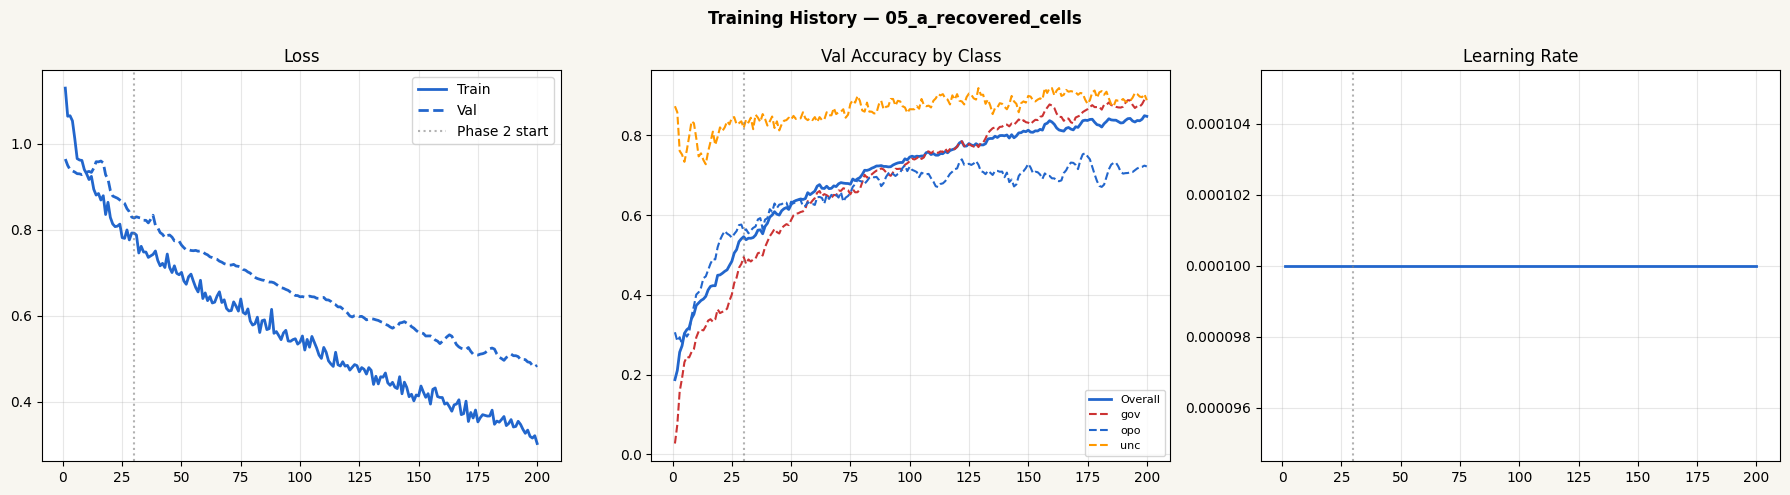

Training curve saved: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/models/05_a_recovered_cells/training_curves.png


In [9]:
# ── CELL 7: Training Curves ──────────────────────────────────────────────────
OUT_DIR_EXP = MODELS_DIR / EXPERIMENT_NAME
OUT_DIR_EXP.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#F8F6F0')
fig.suptitle(f'Training History — {EXPERIMENT_NAME}', fontsize=12, fontweight='bold')

epochs = range(1, len(history_exp['train_loss']) + 1)
col = '#2266CC'

ax = axes[0]
ax.plot(epochs, history_exp['train_loss'], color=col, lw=2, label='Train')
ax.plot(epochs, history_exp['val_loss'],   color=col, lw=2, ls='--', label='Val')
ax.axvline(FREEZE_EPOCHS, color='grey', ls=':', alpha=0.6, label='Phase 2 start')
ax.set_title('Loss'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs, history_exp['val_acc'],          color=col,       lw=2,   label='Overall')
ax.plot(epochs, history_exp['val_acc_gov'],       color='#CC3333', lw=1.5, ls='--', label='gov')
ax.plot(epochs, history_exp['val_acc_opo'],       color='#2266CC', lw=1.5, ls='--', label='opo')
ax.plot(epochs, history_exp['val_acc_uncertain'], color='#FF9900', lw=1.5, ls='--', label='unc')
ax.axvline(FREEZE_EPOCHS, color='grey', ls=':', alpha=0.6)
ax.set_title('Val Accuracy by Class'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(epochs, history_exp['lr'], color=col, lw=2)
ax.axvline(FREEZE_EPOCHS, color='grey', ls=':', alpha=0.6)
ax.set_title('Learning Rate'); ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = OUT_DIR_EXP / 'training_curves.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Training curve saved: {fig_path}')


---
## 10 · Export Predictions

Saves a flat CSV with one row per labelled cell-month, covering all 29 months (train + validation). The `is_train_month` column lets downstream notebooks filter to the held-out validation window.


In [10]:
# ── CELL 8: Export Predictions ───────────────────────────────────────────────
import torch.nn.functional as F_export

OUT_DIR_EXP = MODELS_DIR / EXPERIMENT_NAME
OUT_DIR_EXP.mkdir(parents=True, exist_ok=True)

model_exp.eval()
all_pred_rows = []

with torch.no_grad():
    for i_m, month in enumerate(month_keys):
        X_t    = torch.from_numpy(X_array[i_m]).unsqueeze(0).to(DEVICE)
        logits = model_exp(X_t)
        probs  = F_export.softmax(logits, dim=1)[0].cpu().numpy()
        preds  = logits.argmax(dim=1)[0].cpu().numpy()

        month_rows = labelled[labelled['year_month'] == month]
        for _, row in month_rows.iterrows():
            gid = row['priogrid_gid']
            if gid not in gid_to_local: continue
            lr, lc = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
            pred_int = int(preds[lr, lc])
            all_pred_rows.append({
                'priogrid_gid'   : int(gid),
                'year_month'     : month,
                'pred_class'     : INV_LABEL[pred_int],
                'pred_class_int' : pred_int,
                'prob_gov'       : float(probs[0, lr, lc]),
                'prob_opo'       : float(probs[1, lr, lc]),
                'prob_uncertain' : float(probs[2, lr, lc]),
                'confidence'     : float(probs[:, lr, lc].max()),
                'true_class'     : row['target'],
                'has_label'      : True,
                'is_train_month' : month <= TRAIN_CUTOFF,
            })

pred_csv = pd.DataFrame(all_pred_rows)
pred_path = OUT_DIR_EXP / 'predictions.csv'
pred_csv.to_csv(pred_path, index=False)
print(f'Predictions saved: {pred_path}  ({len(pred_csv):,} rows)')
print(f'Val rows: {(pred_csv["is_train_month"] == False).sum():,}')


Predictions saved: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/models/05_a_recovered_cells/predictions.csv  (5,180 rows)
Val rows: 2,562


---
## 11 · Evaluation

All metrics below are computed **on the validation set only** (`is_train_month == False`), which covers the held-out period after `TRAIN_CUTOFF`. The model never saw these months during training.

### What we measure
| Metric | What it captures |
|---|---|
| **Accuracy** | Fraction of cells labelled correctly |
| **Precision** | Of all cells predicted as class X, how many actually are X? |
| **Recall** | Of all true class-X cells, how many did the model find? |
| **F1** | Harmonic mean of precision and recall — balances both |
| **Confusion matrix** | Which classes get confused with which |

### Transition analysis
A *transition* is a cell that changes its true label from month t−1 to month t. These are the most important predictions for the World Bank use case — mapping *changes* in territorial control. We count how many transitions the model correctly predicted vs missed, broken down by direction (e.g. gov→opo vs opo→gov).


In [11]:
# ── CELL 9: Overall Metrics on Validation Set ────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

pred_csv = pd.read_csv(OUT_DIR_EXP / 'predictions.csv')
val_df   = pred_csv[pred_csv['is_train_month'] == False].copy()

LABEL_MAP_R = {'gov': 0, 'opo': 1, 'uncertain': 2}
val_df['true_int'] = val_df['true_class'].map(LABEL_MAP_R)
val_df['pred_int'] = val_df['pred_class'].map(LABEL_MAP_R)

y_true = val_df['true_int'].values
y_pred = val_df['pred_int'].values
n_val  = len(val_df)

print('=' * 60)
print(f'VALIDATION SET  ({val_df["year_month"].nunique()} months, {n_val:,} cell-months)')
print('=' * 60)

report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

# Pretty-print as table
print(f'\n{"Class":<14} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Support":>10}')
print('-' * 56)
for cls in CLASS_NAMES:
    r = report[cls]
    sup = int(r['support'])
    sup_pct = 100 * sup / n_val
    print(f'{cls:<14} {r["precision"]:>9.1%}  {r["recall"]:>9.1%}  {r["f1-score"]:>9.1%}'
          f'  {sup:>6,} ({sup_pct:.1f}%)')
print('-' * 56)
print(f'{"macro avg":<14} {report["macro avg"]["precision"]:>9.1%}  '
      f'{report["macro avg"]["recall"]:>9.1%}  {report["macro avg"]["f1-score"]:>9.1%}  '
      f'{n_val:>6,} (100%)')
print(f'{"weighted avg":<14} {report["weighted avg"]["precision"]:>9.1%}  '
      f'{report["weighted avg"]["recall"]:>9.1%}  {report["weighted avg"]["f1-score"]:>9.1%}')

overall_acc = (y_true == y_pred).mean()
baseline_acc = (y_true == 0).mean()  # always predict gov
print(f'\nOverall accuracy   : {overall_acc:.1%}  ({(y_true == y_pred).sum():,} / {n_val:,})')
print(f'Baseline (all-gov) : {baseline_acc:.1%}  ({(y_true == 0).sum():,} / {n_val:,})')
print(f'Improvement vs baseline: +{(overall_acc - baseline_acc):.1%}')


VALIDATION SET  (14 months, 2,562 cell-months)

Class           Precision     Recall         F1    Support
--------------------------------------------------------
gov                90.3%      88.8%      89.6%   1,646 (64.2%)
opo                84.1%      72.4%      77.8%     641 (25.0%)
uncertain          63.2%      89.8%      74.2%     275 (10.7%)
--------------------------------------------------------
macro avg          79.2%      83.7%      80.5%   2,562 (100%)
weighted avg       85.8%      84.8%      85.0%

Overall accuracy   : 84.8%  (2,173 / 2,562)
Baseline (all-gov) : 64.2%  (1,646 / 2,562)
Improvement vs baseline: +20.6%


### Confusion Matrix
Rows = true class, columns = predicted class. The **left panel** shows raw cell counts; the **right panel** normalises each row to 1.0 so recall is on the diagonal.

High off-diagonal values in the normalised matrix indicate systematic confusion between a pair of classes.


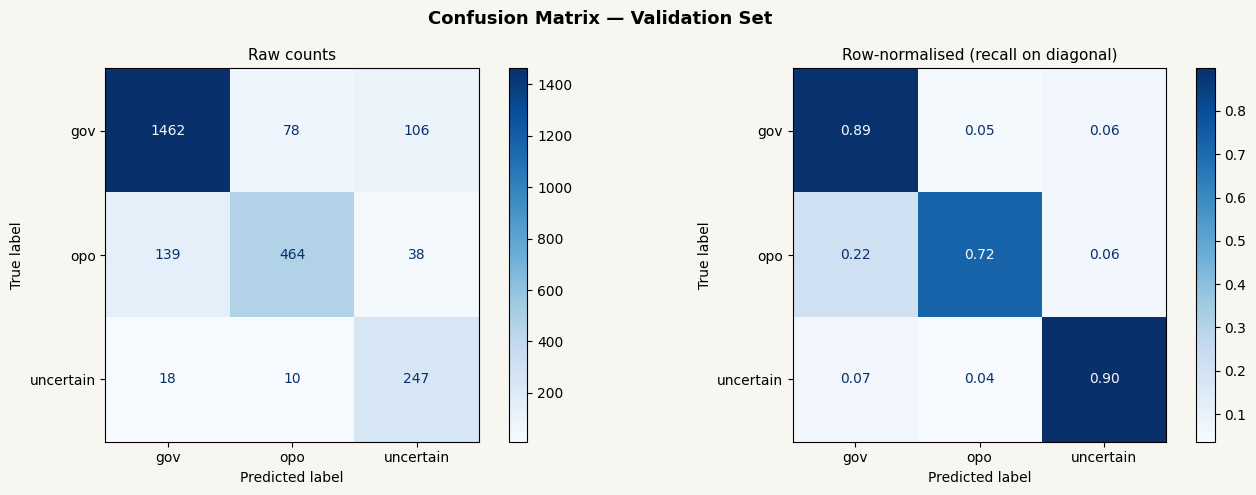

Confusion matrix details:
  True       gov → predicted       opo:   78 cells  (4.7% of true gov)
  True       gov → predicted uncertain:  106 cells  (6.4% of true gov)
  True       opo → predicted       gov:  139 cells  (21.7% of true opo)
  True       opo → predicted uncertain:   38 cells  (5.9% of true opo)
  True uncertain → predicted       gov:   18 cells  (6.5% of true uncertain)
  True uncertain → predicted       opo:   10 cells  (3.6% of true uncertain)


In [12]:
# ── CELL 10: Confusion Matrix ────────────────────────────────────────────────
cm      = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#F8F6F0')
fig.suptitle('Confusion Matrix — Validation Set', fontsize=13, fontweight='bold')

ax = axes[0]
ax.set_facecolor('#F8F6F0')
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap='Blues', colorbar=True, values_format='d')
ax.set_title('Raw counts', fontsize=11)

ax = axes[1]
ax.set_facecolor('#F8F6F0')
ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap='Blues', colorbar=True, values_format='.2f')
ax.set_title('Row-normalised (recall on diagonal)', fontsize=11)

plt.tight_layout()
fig.savefig(OUT_DIR_EXP / 'eval_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Confusion matrix details:')
for i, true_cls in enumerate(CLASS_NAMES):
    for j, pred_cls in enumerate(CLASS_NAMES):
        n = cm[i, j]
        pct = 100 * cm_norm[i, j]
        if i != j and n > 0:
            print(f'  True {true_cls:>9} → predicted {pred_cls:>9}: {n:4d} cells  ({pct:.1f}% of true {true_cls})')


---
### Transition Analysis

A **transition** is a cell where the ground-truth label changes between consecutive months within the validation window. These are the hardest and most important cases: the model must not just maintain a stable prediction but actually *shift* its output when the battlefield changes.

We compute for each cell in the validation set:
- `prev_label` = true label in the previous month (NaN for the first validation month)
- `is_transition` = True if the label changed

Then for each transition type `from → to`, we count how many times the model correctly predicted the new label (`to`) and how many times it missed.


In [13]:
# ── CELL 11: Transition Analysis ─────────────────────────────────────────────
val_sorted = val_df.sort_values(['priogrid_gid', 'year_month']).copy()

# Compute previous true label within the val window for each cell
val_sorted['prev_true_int'] = val_sorted.groupby('priogrid_gid')['true_int'].shift(1)

# Identify transitions
transitions = val_sorted.dropna(subset=['prev_true_int']).copy()
transitions['prev_true_int'] = transitions['prev_true_int'].astype(int)
transitions['is_transition']  = transitions['true_int'] != transitions['prev_true_int']

trans_only = transitions[transitions['is_transition']].copy()
stable     = transitions[~transitions['is_transition']].copy()

n_trans  = len(trans_only)
n_stable = len(stable)
n_total  = len(transitions)

print('=' * 60)
print('TRANSITION SUMMARY (validation window)')
print('=' * 60)
print(f'  Total cell-months with a previous label: {n_total:,}')
print(f'  Stable cell-months (no change)          : {n_stable:,}  ({100*n_stable/n_total:.1f}%)')
print(f'  Transition cell-months (label changed)  : {n_trans:,}  ({100*n_trans/n_total:.1f}%)')

# Model performance on transitions vs stable cells
trans_correct  = (trans_only['true_int'] == trans_only['pred_int']).sum()
stable_correct = (stable['true_int']     == stable['pred_int']).sum()

print(f'\n  Accuracy on STABLE  cells: {stable_correct}/{n_stable} = {100*stable_correct/n_stable:.1f}%')
print(f'  Accuracy on TRANSITION cells: {trans_correct}/{n_trans} = {100*trans_correct/n_trans:.1f}%')

# Per-direction breakdown
print('\n' + '=' * 60)
print('TRANSITION BREAKDOWN  (from → to)')
print('=' * 60)
print(f'  {"Transition":<22} {"Count":>6}  {"Correct":>8}  {"Hit rate":>10}  {"Notes"}')
print('  ' + '-' * 56)

trans_only['from_cls'] = trans_only['prev_true_int'].map(INV_LABEL)
trans_only['to_cls']   = trans_only['true_int'].map(INV_LABEL)
trans_only['hit']      = trans_only['true_int'] == trans_only['pred_int']

for from_c in CLASS_NAMES:
    for to_c in CLASS_NAMES:
        if from_c == to_c:
            continue
        subset = trans_only[(trans_only['from_cls'] == from_c) & (trans_only['to_cls'] == to_c)]
        if len(subset) == 0:
            continue
        n_dir     = len(subset)
        n_correct = subset['hit'].sum()
        hit_rate  = n_correct / n_dir
        note = '✓ good' if hit_rate >= 0.5 else ('✗ poor' if hit_rate < 0.25 else '~ ok')
        print(f'  {from_c:>9} → {to_c:<9}  {n_dir:>6,}  {n_correct:>8,}  {hit_rate:>9.1%}  {note}')


TRANSITION SUMMARY (validation window)
  Total cell-months with a previous label: 2,379
  Stable cell-months (no change)          : 2,319  (97.5%)
  Transition cell-months (label changed)  : 60  (2.5%)

  Accuracy on STABLE  cells: 1975/2319 = 85.2%
  Accuracy on TRANSITION cells: 27/60 = 45.0%

TRANSITION BREAKDOWN  (from → to)
  Transition              Count   Correct    Hit rate  Notes
  --------------------------------------------------------
        gov → opo            22         7      31.8%  ~ ok
        gov → uncertain       5         4      80.0%  ✓ good
        opo → gov            20        12      60.0%  ✓ good
        opo → uncertain       2         2     100.0%  ✓ good
  uncertain → gov             8         2      25.0%  ~ ok
  uncertain → opo             3         0       0.0%  ✗ poor


### What the transition analysis tells us
- **High hit rate (≥50%)**: the model reliably detects this type of movement
- **Low hit rate (<25%)**: the model systematically misses this type of movement — the features available at prediction time may not contain a strong enough signal for this transition direction
- The hardest transitions are typically those into `uncertain`, because the model must recognise ambiguity rather than committing to a clear side

The raw counts matter too: a 20% hit rate on 5 transitions is much less concerning than 20% on 50.


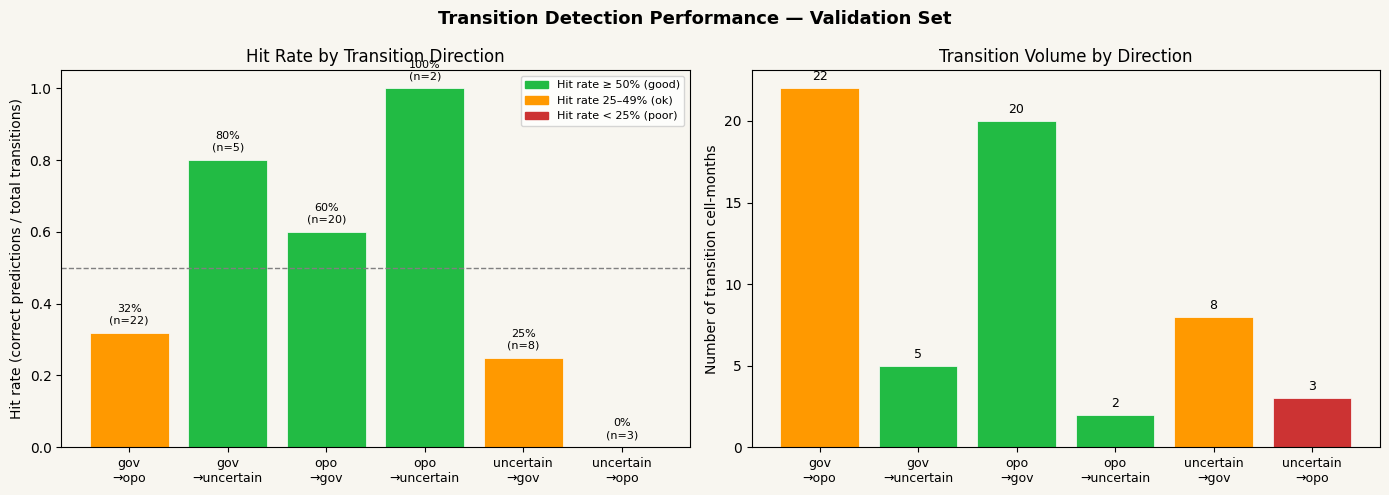

Transition chart saved.


In [14]:
# ── CELL 12: Transition Hit-Rate Bar Chart ───────────────────────────────────
from itertools import product as iproduct

directions = [(f, t) for f in CLASS_NAMES for t in CLASS_NAMES if f != t]
counts   = []
hit_rates = []
labels_bar = []

for from_c, to_c in directions:
    sub = trans_only[(trans_only['from_cls'] == from_c) & (trans_only['to_cls'] == to_c)]
    if len(sub) == 0:
        continue
    counts.append(len(sub))
    hit_rates.append(sub['hit'].mean())
    labels_bar.append(f'{from_c}\n→{to_c}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#F8F6F0')
fig.suptitle('Transition Detection Performance — Validation Set',
             fontsize=13, fontweight='bold')

x = np.arange(len(labels_bar))
bar_colors = ['#22BB44' if h >= 0.5 else ('#FF9900' if h >= 0.25 else '#CC3333')
              for h in hit_rates]

ax = axes[0]
ax.set_facecolor('#F8F6F0')
bars = ax.bar(x, hit_rates, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.axhline(0.5, color='grey', ls='--', lw=1, label='50% threshold')
ax.set_xticks(x); ax.set_xticklabels(labels_bar, fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Hit rate (correct predictions / total transitions)')
ax.set_title('Hit Rate by Transition Direction')
ax.legend(fontsize=9)
for bar, h, n in zip(bars, hit_rates, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{h:.0%}\n(n={n})', ha='center', va='bottom', fontsize=8)

ax = axes[1]
ax.set_facecolor('#F8F6F0')
bars2 = ax.bar(x, counts, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(labels_bar, fontsize=9)
ax.set_ylabel('Number of transition cell-months')
ax.set_title('Transition Volume by Direction')
for bar, n in zip(bars2, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(n), ha='center', va='bottom', fontsize=9)

patches = [
    mpatches.Patch(color='#22BB44', label='Hit rate ≥ 50% (good)'),
    mpatches.Patch(color='#FF9900', label='Hit rate 25–49% (ok)'),
    mpatches.Patch(color='#CC3333', label='Hit rate < 25% (poor)'),
]
axes[0].legend(handles=patches, fontsize=8, loc='upper right')

plt.tight_layout()
fig.savefig(OUT_DIR_EXP / 'eval_transitions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Transition chart saved.')


---
### Summary Table

Quick-reference numbers for the write-up.


In [15]:
# ── CELL 13: Summary Table ────────────────────────────────────────────────────
print('=' * 60)
print('EXPERIMENT 05_a — SUMMARY (validation set)')
print('=' * 60)
print(f'  Months (train / val)  : {len(train_idx)} / {len(val_idx)}')
print(f'  Cells in model        : {labelled["priogrid_gid"].nunique()} (185 with left join)')
print(f'  Val cell-months       : {n_val:,}')
print()
print(f'  Overall accuracy      : {overall_acc:.1%}')
print(f'  All-gov baseline      : {baseline_acc:.1%}')
print(f'  Lift vs baseline      : +{(overall_acc - baseline_acc):.1%}')
print()
print(f'  Per-class F1:')
for cls in CLASS_NAMES:
    f1  = report[cls]['f1-score']
    rec = report[cls]['recall']
    pre = report[cls]['precision']
    sup = int(report[cls]['support'])
    print(f'    {cls:<12} F1={f1:.1%}  prec={pre:.1%}  rec={rec:.1%}  n={sup:,}')
print()
print(f'  Macro F1              : {report["macro avg"]["f1-score"]:.1%}')
print(f'  Weighted F1           : {report["weighted avg"]["f1-score"]:.1%}')
print()
print(f'  Transition hit rate   : {100*trans_correct/n_trans:.1f}%  ({trans_correct}/{n_trans})')
print(f'  Stable cell accuracy  : {100*stable_correct/n_stable:.1f}%  ({stable_correct}/{n_stable})')


EXPERIMENT 05_a — SUMMARY (validation set)
  Months (train / val)  : 15 / 14
  Cells in model        : 185 (185 with left join)
  Val cell-months       : 2,562

  Overall accuracy      : 84.8%
  All-gov baseline      : 64.2%
  Lift vs baseline      : +20.6%

  Per-class F1:
    gov          F1=89.6%  prec=90.3%  rec=88.8%  n=1,646
    opo          F1=77.8%  prec=84.1%  rec=72.4%  n=641
    uncertain    F1=74.2%  prec=63.2%  rec=89.8%  n=275

  Macro F1              : 80.5%
  Weighted F1           : 85.0%

  Transition hit rate   : 45.0%  (27/60)
  Stable cell accuracy  : 85.2%  (1975/2319)
